# Assignment 3: LLMs and Machine Learning

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 0a) Set up Ollama
from openai import OpenAI

# Connect to the local Ollama server
ollama_client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"  # required by the library but ignored by Ollama
)

def ask_llm(prompt, model):
    """Send a prompt to a local Ollama model and return the response text."""
    response = ollama_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

print("Ollama client configured.")



Ollama client configured.


In [20]:
# 0b) 270m parameter version of gemma3

MODEL_SMALL = "gemma3:270m"

response_small = ask_llm(
    "What is supervised machine learning? Answer in one sentence.",
    MODEL_SMALL
)

print(f"gemma3 small ({MODEL_SMALL}):")
print(response_small)

gemma3 small (gemma3:270m):
Supervised machine learning is a type of machine learning that uses labeled data to train models on a dataset to learn a task.



In [7]:
# 0c) 1b parameter version of gemma3

MODEL_LARGE = "gemma3:1b"

response_large = ask_llm(
    "What is supervised machine learning? Answer in one sentence.",
    MODEL_LARGE
)

print(f"gemma3 large ({MODEL_LARGE}):")
print(response_large)

gemma3 large (gemma3:1b):
Supervised machine learning uses labeled data to train algorithms to learn a mapping from inputs to desired outputs, allowing the machine to make predictions or decisions based on this learned relationship.


### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [9]:
# Load the emails dataset
emails = pd.read_csv("data/emails.csv", sep="\t")
display(emails.head())

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review


In [10]:
# 1a) Classify function
def classify_email(headline, model):
    prompt = (
        "Classify the following email headline into exactly one category.\n\n"
        "Categories:\n"
        "- spam: clearly suspicious, promotional, scam-like, sexual, prize-related, urgent account threat, or malicious\n"
        "- work: clearly professional, related to meetings, reports, reviews, projects, manuscripts, budgets, or colleagues\n"
        "- unknown: too vague to classify confidently\n\n"
        "Rules:\n"
        "- Do not explain your answer.\n"
        "- Respond with only one word: spam, work, or unknown.\n"
        "- If the headline is too vague, choose unknown.\n\n"
        f"Headline: {headline}"
    )
    
    return ask_llm(prompt, model).strip().lower()

In [11]:
# 1b) Classify with small model
headline_col = emails.columns[0]

emails["classification_small"] = emails[headline_col].apply(
    lambda h: classify_email(h, MODEL_SMALL)
)

display(emails[[headline_col, "classification_small"]])

,headline,classification_small
0,URGENT: Your account will be suspended within ...,unknown
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,unknown
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",wav
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",unknown
8,Quick question about last week,unknown
9,Following up,spam


In [12]:
# 1c) Classify with large model
emails["classification_large"] = emails[headline_col].apply(
    lambda h: classify_email(h, MODEL_LARGE)
)

display(emails[[headline_col, "classification_small", "classification_large"]])

,headline,classification_small,classification_large
0,URGENT: Your account will be suspended within ...,unknown,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,unknown,unknown
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work
4,Meeting agenda for Thursday's project review,spam,work
5,"Q3 budget report attached, please review by Fr...",wav,work
6,Reminder: Annual performance review scheduled ...,work,work
7,"Updated draft of the manuscript, comments welcome",unknown,work
8,Quick question about last week,unknown,unknown
9,Following up,spam,unknown


The large model works better overall. It correctly marks more normal work emails as work, while the small model often says unknown or marks them as spam. The small model is less reliable because it even gives an invalid answer, "wav". The large model still makes mistakes, for example with the hot singles in your area email, so the results should still be checked manually.

In [13]:
# 1d) Iterating 
results = pd.DataFrame()
results["headline"] = emails[headline_col]

for run in range(1, 4):
    small_labels = []
    large_labels = []
    
    for headline in emails[headline_col]:
        small_label = classify_email(headline, MODEL_SMALL)
        large_label = classify_email(headline, MODEL_LARGE)
        
        small_labels.append(small_label)
        large_labels.append(large_label)
    
    results[f"small_run_{run}"] = small_labels
    results[f"large_run_{run}"] = large_labels

display(results)

,headline,small_run_1,large_run_1,small_run_2,large_run_2,small_run_3,large_run_3
0,URGENT: Your account will be suspended within ...,spam,spam,urgent,spam,work,spam
1,Congratulations! You have won a 1000€ gift car...,work,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,unknown,unknown,spam,work,unknown
3,Re: Inheritance transfer of 4.5M USD pending y...,work,work,unknown,work,work,work
4,Meeting agenda for Thursday's project review,unknown,work,unknown,work,unknown,work
5,"Q3 budget report attached, please review by Fr...",unknown,work,spam,work,spam,work
6,Reminder: Annual performance review scheduled ...,work,work,reminder,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,unknown,work,unknown,work
8,Quick question about last week,unknown,unknown,unknown,unknown,spam,unknown
9,Following up,spam,unknown,work,unknown,spam,unknown


#### 1d) Results
The larger model produced more accurate and consistent classifications than the smaller 270m model. The large model better handles vague ("unknown") headlines and is less likely to misclassify work emails as spam. The smaller model occasionally struggles to follow the output format strictly, sometimes returning extra words rather than just the single label. For the first row in small_run_3, the output is "urgent", which is obviously breaks the instructions given to the model. This is expected because the larger model has more alot more parameters and therefore greater language understanding.s.

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [16]:
# Load the financial news dataset
news = pd.read_csv("data/news.csv", sep="\t")
display(news.head())

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...


In [17]:
# 2a) 
def classify_news(headline, model):
    """Classify a financial news headline and return a Python dict with topic and sentiment."""
    prompt = (
        f"Classify the following financial news headline.\n"
        f"Return a JSON object with exactly two keys:\n"
        f"- \"topic\": one of earnings, mergers, regulation, macroeconomics\n"
        f"- \"sentiment\": one of positive, negative, neutral\n\n"
        f"Do not include any other text, markdown formatting, or code blocks. Return only the JSON object.\n\n"
        f"Headline: {headline}"
    )
    result = ask_llm(prompt, model)
    # Strip markdown code fences if the model adds them
    cleaned = result.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    return json.loads(cleaned)

# Test on the first headline
headline_col_news = news.columns[0]
test_result = classify_news(news.iloc[0][headline_col_news], MODEL_LARGE)
print(f"Headline: {news.iloc[0][headline_col_news]}")
print(f"Result: {json.dumps(test_result, indent=2)}")


Headline: Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
Result: {
  "topic": "earnings",
  "sentiment": "positive"
}


In [18]:
# 2b) Apply classification to all rows

classifications = news[headline_col_news].apply(
    lambda h: classify_news(h, MODEL_LARGE)
)

# Build the result df
news_classified = news.copy()
news_classified["topic"] = classifications.apply(lambda d: d.get("topic", ""))
news_classified["sentiment"] = classifications.apply(lambda d: d.get("sentiment", ""))

display(news_classified)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,positive
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,mergers,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### 2c) Browser-based vs. local gemma

Gemini output:

| Headline | Topic | Sentiment |
| :--- | :--- | :--- |
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics |

The browser-based Gemini is generally more accurate and more careful when making distinctions than the local model is. Gemini managed to classify neutral cases much better. The browser model likely performs better because it has more parameters, is better at following instructions and has a stronger language understanding. With this financial news data set, language understanding is required to "read between the lines" when it comes to identifying expectations of financial actors. For example, "in line with analyst expectations" should be treated as a neutral due to the market's expectations matching the outcome, but gemma classifies it as sentiment positive.
 negative |s,negative

### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


#### 3a) Import data and conduct exploratory analysis


In [22]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [23]:
# The dataset file has manually been extracted into the correct data folder
bank = pd.read_csv("data/bank-additional.csv", sep=";")
display(bank.head())

bank.info()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [24]:
# Summary stats for numeric columns
display(bank.describe().round(2))

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00
mean,40.11,256.79,2.54,960.42,0.19,0.08,93.58,-40.50,3.62,5166.48
std,10.31,254.70,2.57,191.92,0.54,1.56,0.58,4.59,1.73,73.67
min,18.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.64,4963.60
25%,32.00,103.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.33,5099.10
50%,38.00,181.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,317.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,88.00,3643.00,35.00,999.00,6.00,1.40,94.77,-26.90,5.04,5228.10


In [25]:
# Check class balance of target variable
print("Target variable distribution:")
print(bank["y"].value_counts())
print()
print("Class proportions:")
print(bank["y"].value_counts(normalize=True).round(3))

Target variable distribution:
y
no     3668
yes     451
Name: count, dtype: int64

Class proportions:
y
no     0.891
yes    0.109
Name: proportion, dtype: float64


In [26]:
# Check for missing values
print("Missing values per column:")
print(bank.isnull().sum())

# Check for unknown values
print("\n'unknown' value counts per categorical column:")
for col in bank.select_dtypes(include="object").columns:
    n_unknown = (bank[col] == "unknown").sum()
    if n_unknown > 0:
        print(f"  {col}: {n_unknown}")

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

'unknown' value counts per categorical column:
  job: 39
  marital: 11
  education: 167
  default: 803
  housing: 105
  loan: 105


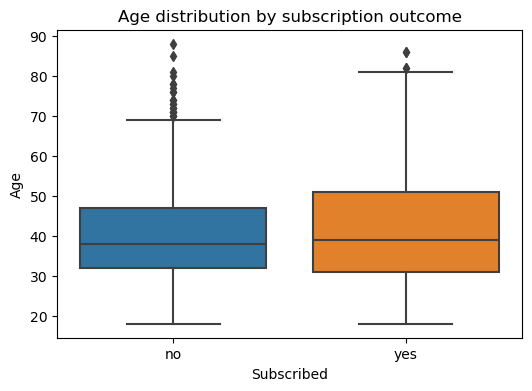

In [27]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=bank, x="y", y="age")
plt.title("Age distribution by subscription outcome")
plt.xlabel("Subscribed")
plt.ylabel("Age")
plt.show()

# The plot is actually not very relevant for the actual analysis

#### 3b) Preprocessing

In [29]:
# Encode the target var: yes --> 1, no --> 0
bank["y"] = bank["y"].map({"yes": 1, "no": 0})
print("Target encoded:", bank["y"].value_counts().to_dict())


Target encoded: {0: 3668, 1: 451}


In [30]:
# One-hot encode all categorical columns
categorical_cols = bank.select_dtypes(include="object").columns.tolist()
bank = pd.get_dummies(bank, columns=categorical_cols, drop_first=True, dtype=float)
print("Shape after encoding:", bank.shape)
bank

Shape after encoding: (4119, 54)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,53,1,999,0,1.4,93.918,-42.7,4.958,5228.1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4115,39,219,1,999,0,1.4,93.918,-42.7,4.959,5228.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4116,27,64,2,999,1,-1.8,92.893,-46.2,1.354,5099.1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4117,58,528,1,999,0,1.4,93.444,-36.1,4.966,5228.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [31]:
# Train/validation/test split: 60% / 20% / 20%
X = bank.drop(columns=["y"])
y = bank["y"]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Standardize numeric features after splitting (to avoid data leakage)
numeric_features = X_train.select_dtypes(include="number").columns.tolist()

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
display(X_train.head())

Train: 2471, Val: 824, Test: 824


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
3387,0.665459,-0.233575,-0.620452,0.207498,-0.355627,-2.200458,-1.583860,2.214014,-1.661399,-2.000309,...,-0.700250,2.775014,-0.129894,-0.128274,-0.515008,-0.520036,1.980482,-0.477631,0.418316,-0.195538
2832,1.249771,-0.559492,-0.212160,0.207498,-0.355627,-1.183790,-0.853459,-1.442310,-1.267148,-0.898300,...,-0.700250,-0.360359,-0.129894,-0.128274,-0.515008,-0.520036,-0.504927,-0.477631,0.418316,-0.195538
1239,0.568074,0.207606,-0.212160,0.207498,-0.355627,0.658921,0.722217,0.859023,0.719648,0.342811,...,1.428062,-0.360359,-0.129894,-0.128274,-0.515008,-0.520036,1.980482,-0.477631,0.418316,-0.195538
595,-0.697934,-0.384610,-0.620452,0.207498,-0.355627,0.849546,1.529773,-0.302397,0.777779,0.843847,...,-0.700250,-0.360359,-0.129894,-0.128274,-0.515008,1.922945,-0.504927,-0.477631,0.418316,-0.195538
3213,0.860230,-0.674755,-0.620452,0.207498,-0.355627,0.849546,-0.220788,0.923547,0.783534,0.843847,...,-0.700250,-0.360359,-0.129894,-0.128274,-0.515008,1.922945,-0.504927,-0.477631,0.418316,-0.195538


#### 3c) Analysis

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y). The target y is also binary, so this is a classification task (will a customer subcribe or not).

These three algorithms were chosen because they classify observations in different ways. 
Random Forest can capture non-linear patterns and interactions between variables, which may be useful when customer behaviour depends on several features at the same tim 

KNN is included as a simple baseline model. It classifies customers based on similar observations, might may struggle when one-hot encoding creates many feas. s.

SVM is suitable because it often works well with high-dimensional data. After encoding the categorical variables, a linear SVM can find a separating boundary between subscribers 


In [34]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#### 3c) i. Random Forest

In [36]:
# Random Forest - tune number of trees and max depth
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
y_pred_rf = grid_rf.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_rf):.4f}")

Best RF params: {'max_depth': None, 'n_estimators': 200}
Validation F1: 0.4173


In [37]:
# Random Forest round 2 — n_estimators was at the edge of the grid, try more trees
grid_rf2 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [200, 400, 600], "max_depth": [None, 20, 30]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_rf2.fit(X_train, y_train)

print("Best RF params:", grid_rf2.best_params_)
y_pred_rf = grid_rf2.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_rf):.4f}")

Best RF params: {'max_depth': None, 'n_estimators': 600}
Validation F1: 0.4397


In [38]:
# Random Forest round 3 - try more trees since n_estimators was again at the edge
grid_rf3 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [500, 700, 1000], "max_depth": [None]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_rf3.fit(X_train, y_train)

print("Best RF params:", grid_rf3.best_params_)
y_pred_rf = grid_rf3.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_rf):.4f}")

Best RF params: {'max_depth': None, 'n_estimators': 500}
Validation F1: 0.4507


In [39]:
# Random Forest round 4 - same amount of trees but with class_weight="balanced" to account for imbalances in class sizes
grid_rf4 = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    {"n_estimators": [500, 700, 1000], "max_depth": [None]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_rf4.fit(X_train, y_train)

print("Best RF params:", grid_rf4.best_params_)
y_pred_rf = grid_rf4.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_rf):.4f}")

Best RF params: {'max_depth': None, 'n_estimators': 500}
Validation F1: 0.3969


Random Forest round 3 has the best performance with F=0.4507

#### 3c) ii. KNN

In [42]:
# KNN round 1 - broad search
grid_knn1 = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": [3, 5, 7, 11, 15, 21]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_knn1.fit(X_train, y_train)

print("Best KNN params:", grid_knn1.best_params_)
y_pred_knn = grid_knn1.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_knn):.4f}")

Best KNN params: {'n_neighbors': 3}
Validation F1: 0.3750


In [43]:
# KNN round 2 - n_neighbors=3 was best, try weighting and distance metrics
grid_knn2 = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": [2, 3, 4, 5, 6],
     "weights": ["uniform", "distance"],
     "metric": ["euclidean", "manhattan"]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_knn2.fit(X_train, y_train)

print("Best KNN params:", grid_knn2.best_params_)
y_pred_knn = grid_knn2.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_knn):.4f}")

Best KNN params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Validation F1: 0.3750


Round 1 searched a broad range of k values. Round 2 narrowed in around the best value from round 1 and implemented different weights and distance measurement combinations. Same result from both rounds: F1=0.3521. Round 2 will be chosen as final KNN model. 

#### 3c) iii. SVM

In [46]:
# SVM round 1 - broad search
grid_svm1 = GridSearchCV(
    SVC(random_state=42),
    {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_svm1.fit(X_train, y_train)

print("Best SVM params:", grid_svm1.best_params_)
y_pred_svm = grid_svm1.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_svm):.4f}")

Best SVM params: {'C': 10, 'kernel': 'linear'}
Validation F1: 0.5035


In [47]:
# SVM round 2 - stay with linear kernel, tune C around best value from round 1
grid_svm2 = GridSearchCV(
    SVC(random_state=42),
    {"C": [5, 8, 10, 12, 15, 20], "kernel": ["linear"]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_svm2.fit(X_train, y_train)

print("Best SVM params:", grid_svm2.best_params_)
y_pred_svm = grid_svm2.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_svm):.4f}")

Best SVM params: {'C': 8, 'kernel': 'linear'}
Validation F1: 0.4930


In [48]:
# SVM round 3 - search between 5 and 10 and try rbf as well 
grid_svm2 = GridSearchCV(
    SVC(random_state=42),
    {"C": [3, 4, 5, 6, 7, 8, 9, 10], "kernel": ["linear", "rbf"]},
    cv=5, scoring="f1", n_jobs=-1
)
grid_svm2.fit(X_train, y_train)

print("Best SVM params:", grid_svm2.best_params_)
y_pred_svm = grid_svm2.best_estimator_.predict(X_val)
print(f"Validation F1: {f1_score(y_val, y_pred_svm):.4f}")

Best SVM params: {'C': 6, 'kernel': 'linear'}
Validation F1: 0.5035


Round 1 tested C values of 0.1, 1, 10 with both rbf and linear kernels, giving C=10 and kernel=linear with F1=0.5035. Round 2 searched between C=3 and C=10 with the linear kernel but F1 did not improve beyond 0.4930. The round 1 model (C=10, kernel=linear) will be chosen as the final SVM model.

### 3d) Train, validation and test set split vs. cross-validation

In [51]:
models = {
    "Random Forest": (grid_rf3.best_estimator_, grid_rf3.best_estimator_.predict(X_val)),
    "KNN":           (grid_knn1.best_estimator_, grid_knn1.best_estimator_.predict(X_val)),
    "SVM":           (grid_svm1.best_estimator_, grid_svm1.best_estimator_.predict(X_val)),
}

print(f"{'Model':<22} {'Val F1':>8} {'CV mean F1':>12} {'CV std':>8}")
print("-" * 54)

for name, (estimator, y_pred_val) in models.items():
    val_f1 = f1_score(y_val, y_pred_val)
    cv_scores = cross_val_score(estimator, X_temp, y_temp, cv=5, scoring="f1", n_jobs=-1)
    print(f"{name:<22} {val_f1:>8.4f} {cv_scores.mean():>12.4f} {cv_scores.std():>8.4f}")

Model                    Val F1   CV mean F1   CV std
------------------------------------------------------
Random Forest            0.4507       0.5100   0.0569
KNN                      0.3750       0.5081   0.0436
SVM                      0.5035       0.4780   0.0662


Random Forest has biggest performance gap by far. KNN and SVM are roughly the when comparing train, validation and test split vs. cross-validation.

Cross-validation gives more reliable performance estimate than a single train/val split because it averages over many different splits rather than depending on one random split. If the CV mean F1 and validation F1 are close, the result is quite trustworthy. A large gap would suggest the single split was lucky or unlucky. The CV standard deviation shows how stable each model is across the different splits.


#### 3e) Evaluation of performance

In [54]:
# Metrics table
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 62)

test_preds = {}
for name, (estimator, _) in models.items():
    y_pred_test = estimator.predict(X_test)
    test_preds[name] = y_pred_test
    print(
        f"{name:<22}"
        f" {accuracy_score(y_test, y_pred_test):>10.4f}"
        f" {precision_score(y_test, y_pred_test):>10.4f}"
        f" {recall_score(y_test, y_pred_test):>8.4f}"
        f" {f1_score(y_test, y_pred_test):>8.4f}"
    )

Model                    Accuracy  Precision   Recall       F1
--------------------------------------------------------------
Random Forest              0.8920     0.5294   0.2935   0.3776
KNN                        0.8823     0.4359   0.1848   0.2595
SVM                        0.8920     0.5246   0.3478   0.4183


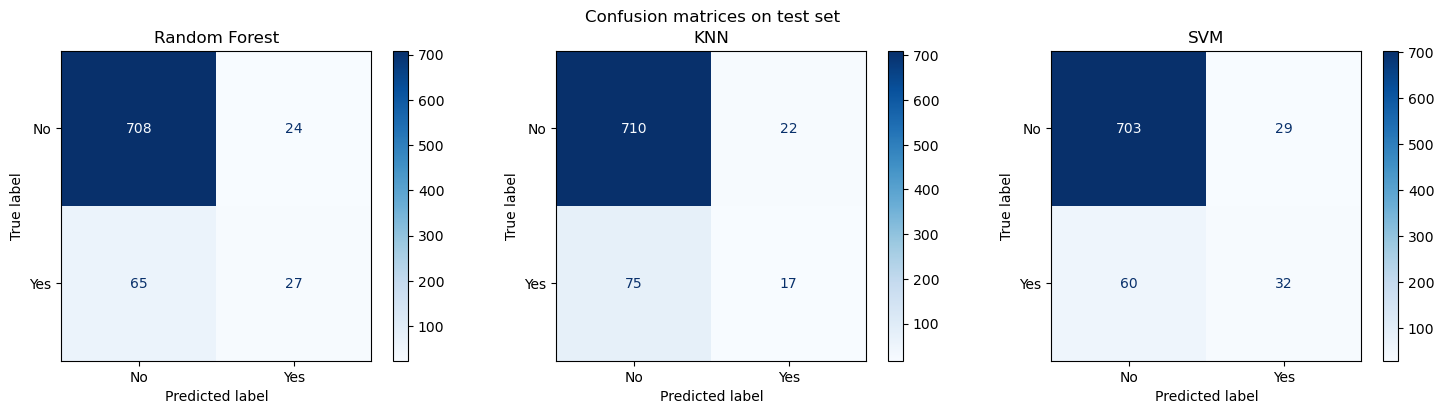

In [55]:
# Confusion matrices on test set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred_test) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion matrices on test set")
plt.tight_layout()
plt.show()

In [56]:
# Full classification reports
for name, y_pred_test in test_preds.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred_test, target_names=["No", "Yes"]))
    print()

===== Random Forest =====
              precision    recall  f1-score   support

          No       0.92      0.97      0.94       732
         Yes       0.53      0.29      0.38        92

    accuracy                           0.89       824
   macro avg       0.72      0.63      0.66       824
weighted avg       0.87      0.89      0.88       824


===== KNN =====
              precision    recall  f1-score   support

          No       0.90      0.97      0.94       732
         Yes       0.44      0.18      0.26        92

    accuracy                           0.88       824
   macro avg       0.67      0.58      0.60       824
weighted avg       0.85      0.88      0.86       824


===== SVM =====
              precision    recall  f1-score   support

          No       0.92      0.96      0.94       732
         Yes       0.52      0.35      0.42        92

    accuracy                           0.89       824
   macro avg       0.72      0.65      0.68       824
weighted avg  

The dataset is heavily imbalanced: around 89% of observations have y = no. Therefore, accuracy alone is misleading. A model that predicts no for every customer would reach about 89% accuracy, but it would fail to identify any actual subscribers. For this reason, the evaluation focuses mainly on the F1-score and recall for the positive class (y = yes).

Looking at the test set results:

- **KNN** performed the worst, with an F1-score of 0.26 and recall of 0.18. This is probably because distance-based methods struggle with the 54 high-dimensional features created by one-hot encoding.
- **Random Forest** performed moderately, with an F1-score of 0.38 and recall of 0.29. It was able to capture more patterns in the data than KNN.
- **SVM** performed best, with an F1-score of 0.42 and recall of 0.35. It identified the most potential subscribers while keeping the number of false alarms at a reasonable level.

**Best model: SVM** with `C = 10` and `kernel = linear`.

SVM achieved the highest F1-score on both the validation set and the test set. It is also well suited to high-dimensional data. The confusion matrix shows that it catches the most true subscribers while keeping false alarms, meaning cases where the model predicts yes but the true value is no, reasonably controlled.


## Statement of AI use

I used AI tools quite extensively during this assignment. AI was used to help understand the task requirements, plan the notebook structure, debug code errors, improve the preprocessing workflow, and explain ML-related concepts in-depth. I also used AI to check and revise parts of the interpretation text.